In [2]:
from PIL import Image
import os
import glob
import cv2 as cv

### Convert .webp to .jpg

In [15]:
input_dir_webp = "../data/webp_unprocessed/"
input_dir_jpeg = "../data/jpeg_unprocessed/"
output_dir = "../data/png_unprocessed/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
files = glob.glob(os.path.join(input_dir_jpeg, "*.jpg"))
files = files + glob.glob(os.path.join(input_dir_webp, "*.webp"))

print(files)

for filepath in files: 
    filename = os.path.basename(filepath)
    image_name = os.path.splitext(filename)[0]

    png_name = os.path.join(output_dir, f"{image_name}.png")
    print(png_name)
    
    img = Image.open(filepath).convert("RGB")
    img.save(png_name, "PNG")


['../data/webp_unprocessed/500PesosBack.webp']
../data/png_unprocessed/500PesosBack.png


In [7]:
import math
import matplotlib.pyplot as plt

def show_images(images, cols=4):
    num_images = len(images)
    rows = math.ceil(num_images / cols)
    
    # Create the figure
    plt.figure(figsize=(15, 5 * rows))
    
    for i, img in enumerate(images):
        # 1. Load the image
        if img is not None:
            # 2. IMPORTANT: Convert BGR (OpenCV default) to RGB (Matplotlib default)
            # img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            
            # 3. Add to subplot
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"Image {i+1}")
            plt.axis('off') # Hide the x/y axis numbers
        else:
            print(f"Could not load: {path}")
            
    plt.tight_layout()
    plt.show()


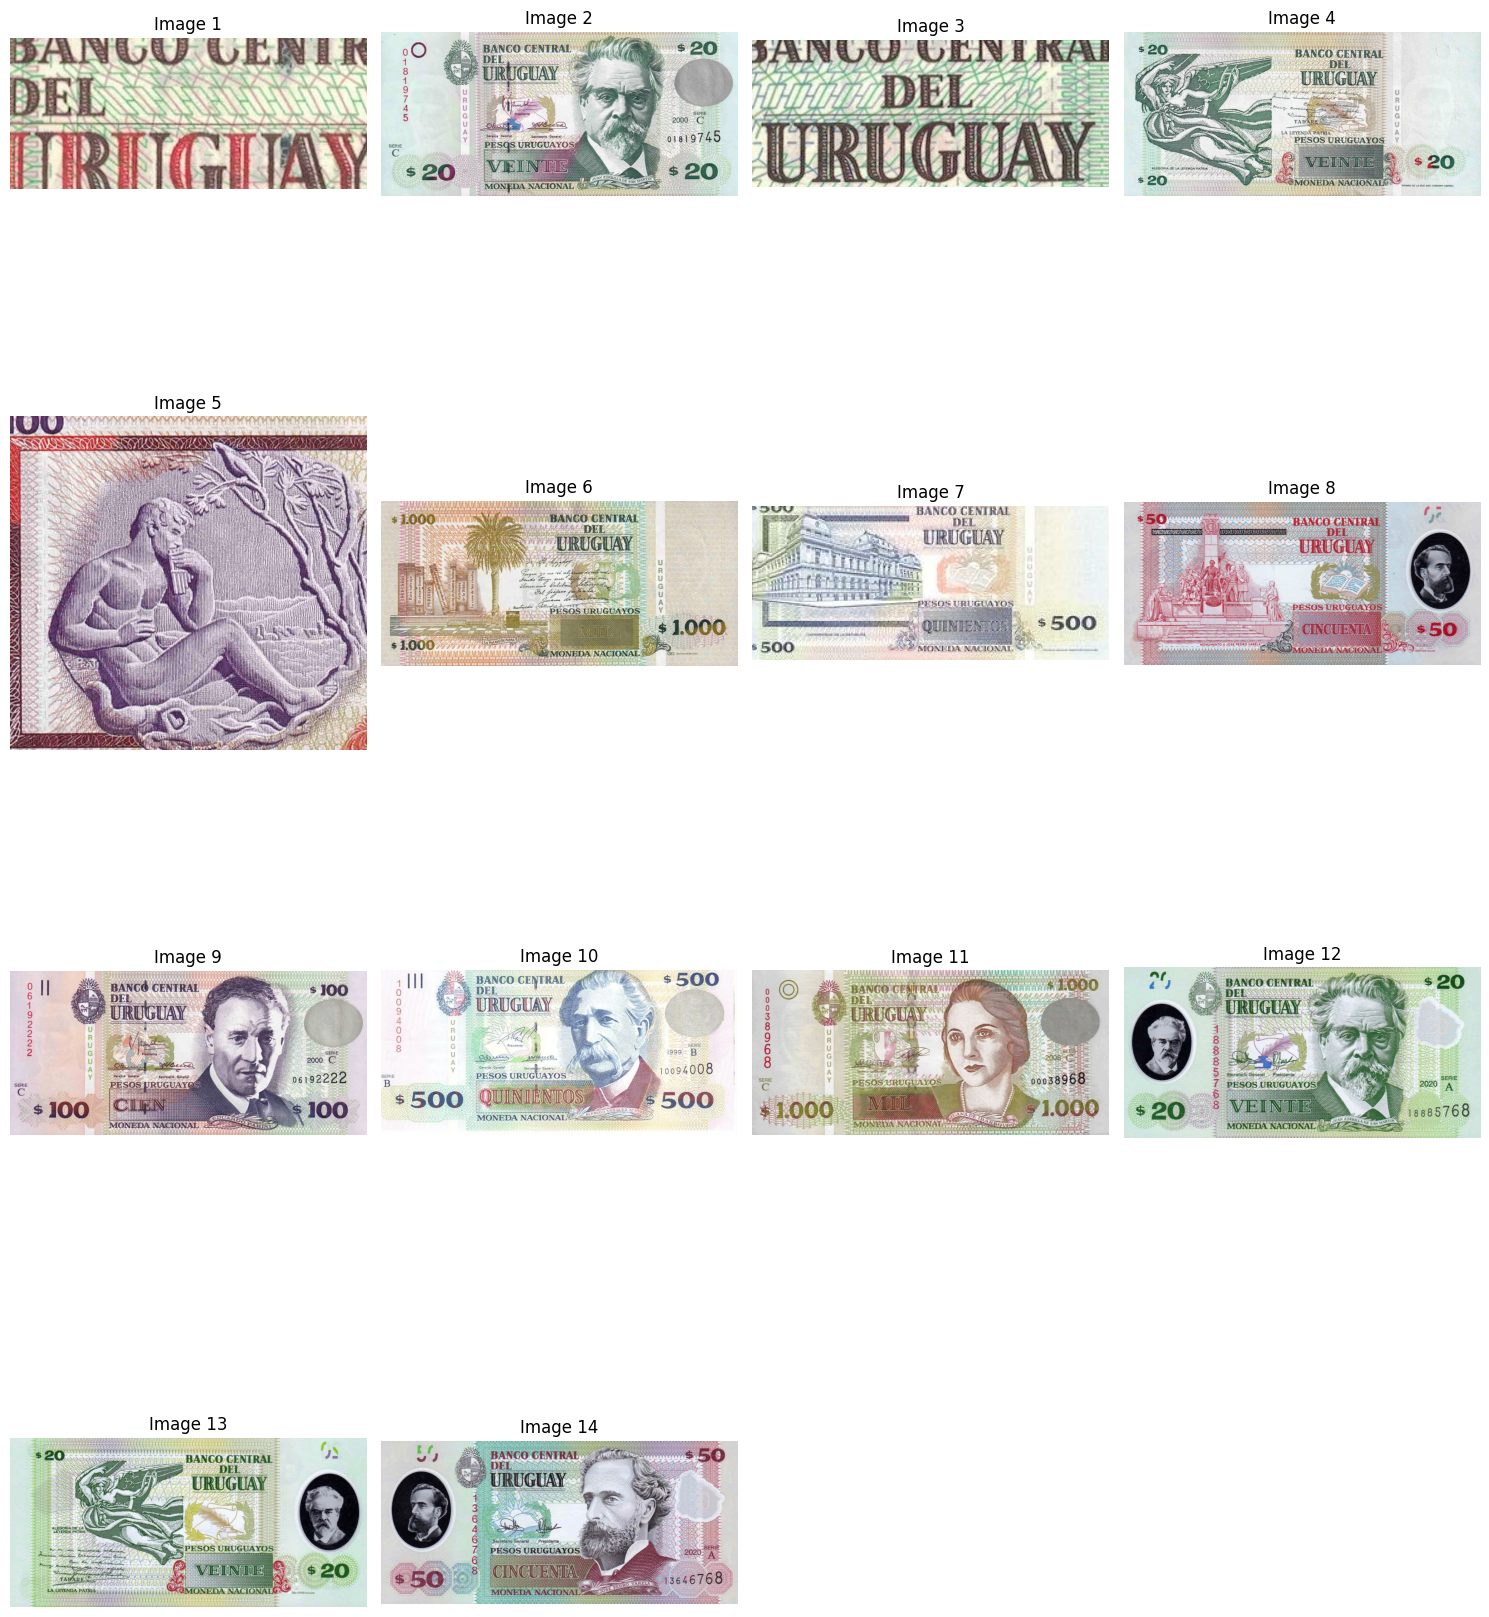

Processing: 200PesosFront.jpg
Saved: ../data/processed_images/clean_200PesosFront.jpg
Processing: 20PesosFront.jpg
Saved: ../data/processed_images/clean_20PesosFront.jpg
Processing: 200PesosBack.jpg
Saved: ../data/processed_images/clean_200PesosBack.jpg
Processing: 20PesosBack.jpg
Saved: ../data/processed_images/clean_20PesosBack.jpg
Processing: 100PesosBack.jpg
Saved: ../data/processed_images/clean_100PesosBack.jpg
Processing: 1000PesosBack.jpg
Saved: ../data/processed_images/clean_1000PesosBack.jpg
Processing: 500PesosBack.jpg
Saved: ../data/processed_images/clean_500PesosBack.jpg
Processing: 50PesosPolimeroBack.jpg
Saved: ../data/processed_images/clean_50PesosPolimeroBack.jpg
Processing: 100PesosFront.jpg
Saved: ../data/processed_images/clean_100PesosFront.jpg
Processing: 500PesosFront.jpg
Saved: ../data/processed_images/clean_500PesosFront.jpg
Processing: 1000PesosFront.jpg
Saved: ../data/processed_images/clean_1000PesosFront.jpg
Processing: 20PesosPolimeroFront.jpg
Saved: ../data/

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

def crop_bill_robust(image_path, trim=15):
    """
    Crops a bill from a solid background.
    trim: Number of pixels to shave off the final crop to eliminate borders.

    This was not used int the final processed_images because of bad results.
    """
    # 1. Load the image
    img = cv.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return None
        
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    # 2. Heavier blur to wash out internal details (faces/numbers)
    blurred = cv.GaussianBlur(gray, (15, 15), 0)
    
    # 3. Detect edges
    edges = cv.Canny(blurred, 30, 150)
    
    # 4. Morphological Closing to "zip up" any gaps in the bill's outline
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (15, 15))
    closed = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel)
    
    # 5. Find contours
    contours, _ = cv.findContours(closed, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("No contours found.")
        return img_rgb
        
    # 6. Get the largest contour
    largest_contour = max(contours, key=cv.contourArea)
    x, y, w, h = cv.boundingRect(largest_contour)
    
    # 7. Apply the trim to shave off the borders, ensuring we don't go out of bounds
    new_x = min(x + trim, img.shape[1])
    new_y = min(y + trim, img.shape[0])
    new_w = max(w - (trim * 2), 1)
    new_h = max(h - (trim * 2), 1)
    
    # 8. Crop using the adjusted coordinates
    cropped_img = img_rgb[new_y:new_y+new_h, new_x:new_x+new_w]
    
    return cropped_img

# --- Processing and Saving Loop ---

input_dir = "../data/jpeg_unprocessed/"
output_dir = "../data/processed_images/"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

files = glob.glob(os.path.join(input_dir, "*.jpg"))

cropped_images = [crop_bill_robust(file, trim=15) for file in files]
show_images(cropped_images)

for filepath in files: 
    # Extract just the filename without the path
    filename = os.path.basename(filepath)
    
    # Run the robust crop
    print(f"Processing: {filename}")
    cropped_img_rgb = crop_bill_robust(filepath, trim=15)
    
    if cropped_img_rgb is not None:
        # Convert back to BGR for saving with OpenCV
        cropped_img_bgr = cv.cvtColor(cropped_img_rgb, cv.COLOR_RGB2BGR)
        
        save_path = os.path.join(output_dir, f"clean_{filename}")
        cv.imwrite(save_path, cropped_img_bgr)
        print(f"Saved: {save_path}")

print("Batch processing complete!")

In [17]:
import cv2 as cv
import os
import glob

# 1. Setup directories
input_dir = "../data/png_unprocessed/"
output_dir = "../data/processed_images/"
os.makedirs(output_dir, exist_ok=True)

# 2. Get all files

files = glob.glob(os.path.join(input_dir, "*.png"))

# 3. Loop through and manually crop
for filepath in files:
    filename = os.path.basename(filepath)
    img = cv.imread(filepath)
    
    if img is None:
        continue
        
    print(f"Cropping: {filename} | Draw box -> Press SPACE to save -> 'c' to skip")
    
    # Opens the interactive window
    x, y, w, h = cv.selectROI("Manual Crop (Press SPACE to confirm)", img, showCrosshair=True, fromCenter=False)
    
    # If a box was drawn, save it
    if w > 0 and h > 0:
        cropped_img = img[y:y+h, x:x+w]
        save_path = os.path.join(output_dir, f"clean_{filename}")
        cv.imwrite(save_path, cropped_img)
        print(f"Saved perfectly to {save_path}\n")
    else:
        print("Skipped.\n")

cv.destroyAllWindows()
print("Manual cropping complete!")

Cropping: 500PesosBack.png | Draw box -> Press SPACE to save -> 'c' to skip
Saved perfectly to ../data/processed_images/clean_500PesosBack.png

Manual cropping complete!


In [18]:
import cv2 as cv
import os
import glob

# 1. Setup your folders
input_dir = "../data/processed_images/"
output_dir = "../data/normalized_images/"
os.makedirs(output_dir, exist_ok=True)

# 2. Set your target width 
# 800px is a great sweet spot: high enough detail for keypoints, small enough to process instantly
TARGET_WIDTH = 800 

# 3. Grab all the clean images you just made
# This looks for any file starting with 'clean_' regardless of extension
files = glob.glob(os.path.join(input_dir, "clean_*.*"))

for filepath in files:
    filename = os.path.basename(filepath)
    
    # Read the image
    img = cv.imread(filepath)
    if img is None:
        continue
        
    # Get current dimensions
    original_height, original_width = img.shape[:2]
    
    # Calculate the new height to maintain the exact same proportions
    aspect_ratio = TARGET_WIDTH / float(original_width)
    new_height = int(original_height * aspect_ratio)
    
    # Resize the image using high-quality interpolation (INTER_AREA is best for shrinking)
    resized_img = cv.resize(img, (TARGET_WIDTH, new_height), interpolation=cv.INTER_AREA)
    
    # Save it to the final database folder
    save_path = os.path.join(output_dir, f"norm_{filename}")
    cv.imwrite(save_path, resized_img)
    
    print(f"Normalized {filename}: {original_width}x{original_height} -> {TARGET_WIDTH}x{new_height}")

print("\nAll images have been perfectly scaled!")

Normalized clean_20PesosBack.png: 1909x890 -> 800x372
Normalized clean_1000PesosBack.png: 1897x881 -> 800x371
Normalized clean_200PesosFront.png: 1883x855 -> 800x363
Normalized clean_1000PesosFront.png: 1891x883 -> 800x373
Normalized clean_20PesosPolimeroBack.png: 1661x803 -> 800x386
Normalized clean_500PesosFront.png: 780x357 -> 800x366
Normalized clean_100PesosFront.png: 1888x870 -> 800x368
Normalized clean_50PesosPolimeroBack.png: 1814x837 -> 800x369
Normalized clean_100PesosBack.png: 1945x900 -> 800x370
Normalized clean_20PesosFront.png: 1933x894 -> 800x369
Normalized clean_500PesosBack.png: 773x357 -> 800x369
Normalized clean_20PesosPolimeroFront.png: 1715x834 -> 800x389
Normalized clean_50PesosPolimeroFront.png: 1713x797 -> 800x372
Normalized clean_200PesosBack.png: 1877x857 -> 800x365

All images have been perfectly scaled!
